<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week4_Day2_Daily_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#Bibliotheque

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import urllib.request

In [4]:
#Exploration des données : Charger et visualiser les données.
from google.colab import files
uploaded = files.upload()

Saving ex2data1.txt to ex2data1 (1).txt


In [5]:

df = pd.read_csv("ex2data1.txt", header=None, names=["exam1", "exam2", "admitted"])

print(" Exploration des données")
print(f"Shape : {df.shape}")
print(df.head())
print(df.describe().round(2))
print(f"\nAdmis     : {(df['admitted']==1).sum()}")
print(f"Non admis : {(df['admitted']==0).sum()}")

=== Exploration des données ===
Shape : (100, 3)
       exam1      exam2  admitted
0  34.623660  78.024693         0
1  30.286711  43.894998         0
2  35.847409  72.902198         0
3  60.182599  86.308552         1
4  79.032736  75.344376         1
        exam1   exam2  admitted
count  100.00  100.00    100.00
mean    65.64   66.22      0.60
std     19.46   18.58      0.49
min     30.06   30.60      0.00
25%     50.92   48.18      0.00
50%     67.03   67.68      1.00
75%     80.21   79.36      1.00
max     99.83   98.87      1.00

Admis     : 60
Non admis : 40


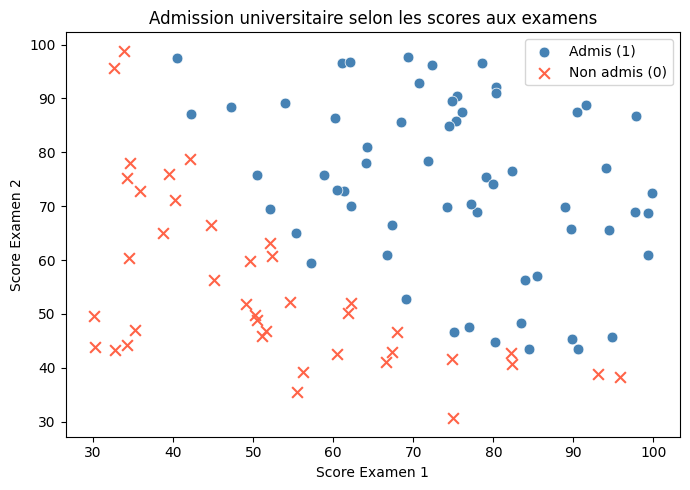

In [8]:
#Créez un nuage de points pour visualiser les données des étudiants admis
#par rapport à ceux qui ne l'ont pas été, en fonction de leurs résultats aux examens.

fig, ax = plt.subplots(figsize=(7, 5))

admis     = df[df['admitted'] == 1]
non_admis = df[df['admitted'] == 0]

ax.scatter(admis['exam1'],     admis['exam2'],     color='steelblue', marker='o',
           edgecolors='white', linewidths=0.5, s=60, label='Admis (1)')
ax.scatter(non_admis['exam1'], non_admis['exam2'], color='tomato',    marker='x',
           s=60, linewidths=1.5, label='Non admis (0)')

ax.set_xlabel('Score Examen 1')
ax.set_ylabel('Score Examen 2')
ax.set_title('Admission universitaire selon les scores aux examens')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# PRÉPARATION DES DONNÉES
# X = les deux scores (features), y = décision d'admission (cible)
X = df[['exam1', 'exam2']].values
y = df['admitted'].values

# --- BLOC 5 : ENTRAÎNEMENT DU MODÈLE ---
# On utilise tout le dataset pour l'entraînement (100 exemples, pas de split)
# car l'objectif est d'illustrer la régression logistique sur ce jeu classique
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X, y)

print("\n=== Paramètres du modèle ===")
print(f"Intercept (θ₀) : {model.intercept_[0]:.4f}")
print(f"Coef exam1 (θ₁) : {model.coef_[0][0]:.4f}")
print(f"Coef exam2 (θ₂) : {model.coef_[0][1]:.4f}")


=== Paramètres du modèle ===
Intercept (θ₀) : -25.0522
Coef exam1 (θ₁) : 0.2054
Coef exam2 (θ₂) : 0.2006


In [11]:
# --- BLOC 6 : PRÉDICTIONS ---
y_pred  = model.predict(X)
y_proba = model.predict_proba(X)[:, 1]

# --- BLOC 7 : ACCURACY ---
acc = accuracy_score(y, y_pred)
print(f"\n=== Évaluation ===")
print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")



=== Évaluation ===
Accuracy : 0.8900 (89.00%)


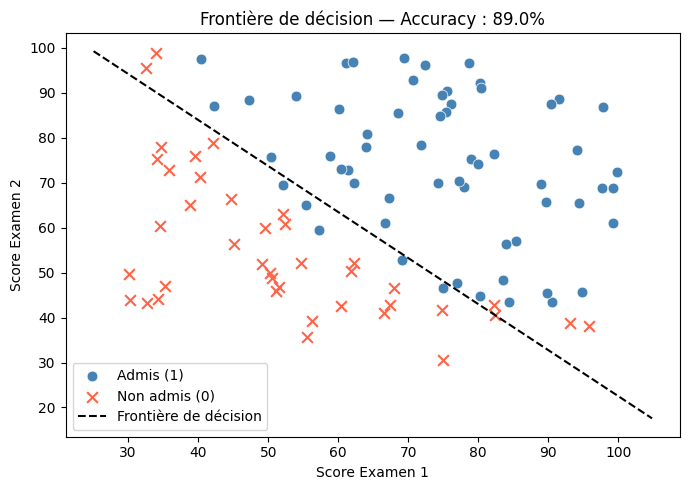

In [12]:
# --- BLOC 8 : FRONTIÈRE DE DÉCISION ---
# La frontière est la droite où P(admis)=0.5, soit θ₀ + θ₁x₁ + θ₂x₂ = 0
# → x₂ = -(θ₀ + θ₁x₁) / θ₂
x1_range = np.linspace(X[:, 0].min() - 5, X[:, 0].max() + 5, 300)
x2_boundary = -(model.intercept_[0] + model.coef_[0][0] * x1_range) / model.coef_[0][1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(admis['exam1'],     admis['exam2'],     color='steelblue', marker='o',
           edgecolors='white', linewidths=0.5, s=60, label='Admis (1)')
ax.scatter(non_admis['exam1'], non_admis['exam2'], color='tomato',    marker='x',
           s=60, linewidths=1.5, label='Non admis (0)')
ax.plot(x1_range, x2_boundary, 'k--', linewidth=1.5, label='Frontière de décision')
ax.set_xlabel('Score Examen 1')
ax.set_ylabel('Score Examen 2')
ax.set_title(f'Frontière de décision — Accuracy : {acc*100:.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

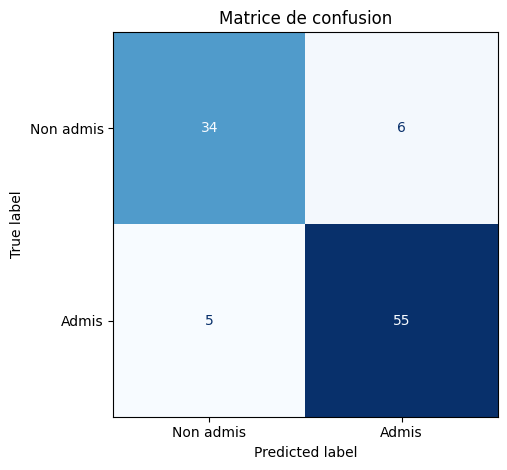

In [13]:
# --- BLOC 9 : MATRICE DE CONFUSION ---
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non admis', 'Admis'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Matrice de confusion')
plt.tight_layout()
plt.show()

In [14]:
# --- BLOC 10 : PRÉDICTION SUR UN NOUVEL ÉTUDIANT ---
# Exemple : un étudiant avec 45 en exam1 et 85 en exam2
new_student = np.array([[45, 85]])
prob = model.predict_proba(new_student)[0][1]
decision = model.predict(new_student)[0]
print(f"\n=== Prédiction nouvel étudiant ===")
print(f"Scores : exam1=45, exam2=85")
print(f"Probabilité d'admission : {prob:.4f} ({prob*100:.1f}%)")
print(f"Décision : {'✅ Admis' if decision == 1 else '❌ Non admis'}")


=== Prédiction nouvel étudiant ===
Scores : exam1=45, exam2=85
Probabilité d'admission : 0.7753 (77.5%)
Décision : ✅ Admis


In [20]:
# --- BLOC exemple  : PRÉDICTION SUR UN NOUVEL ÉTUDIANT ---
# Exemple : un étudiant avec 50 en exam1 et 50 en exam2
new_student = np.array([[50, 50]])
prob = model.predict_proba(new_student)[0][1]
decision = model.predict(new_student)[0]
print(f"\n=== Prédiction nouvel étudiant ===")
print(f"Scores : exam1=50, exam2=50")
print(f"Probabilité d'admission : {prob:.4f} ({prob*100:.1f}%)")
print(f"Décision : {'✅ Admis' if decision == 1 else '❌ Non admis'}")


=== Prédiction nouvel étudiant ===
Scores : exam1=50, exam2=50
Probabilité d'admission : 0.0085 (0.9%)
Décision : ❌ Non admis
